# Final (readable) notebook

In [1]:
import pandas as pd
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


**Data:**
I am using open source data from Kaggle found [here](https://www.kaggle.com/code/minaremon39/celiac-disease-prediction/notebook)

In [2]:
# First, reading in the data from the CSV file
# if you are trying to run this code, make sure you have downloaded the CSV file

filename = "celiac_disease_lab_data.csv"
df = pd.read_csv(filename)
# printing the first 5 rows to make sure the data was read in correctly
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


This has loaded properly, so we will move on to setting up for machine learning. Next, we will look at the datatypes of each variable and look for missing values.

In [3]:
df.isnull().sum()

Age                   0
Gender                0
Diabetes              0
Diabetes_Type       418
Diarrhea              0
Abdominal             0
Short_Stature         0
Sticky_Stool          0
Weight_loss           0
IgA                   0
IgG                   0
IgM                   0
Marsh                 0
cd_type               0
Disease_Diagnose      0
dtype: int64

This means there's 418 missing values in the Diabetes_Type variable that we will have to handle. There aren't any values missing from the .csv file, so something must have happened when reading the data in. We will replace these NA values with 0s since they represent people without diabetes.

In [4]:
df["Diabetes_Type"] = df["Diabetes_Type"].fillna(0)

In [5]:
df.isnull().sum()

Age                 0
Gender              0
Diabetes            0
Diabetes_Type       0
Diarrhea            0
Abdominal           0
Short_Stature       0
Sticky_Stool        0
Weight_loss         0
IgA                 0
IgG                 0
IgM                 0
Marsh               0
cd_type             0
Disease_Diagnose    0
dtype: int64

Now we have no remaining missing values! Let's move on to our types of variables.

In [6]:
df.dtypes

Age                   int64
Gender               object
Diabetes             object
Diabetes_Type        object
Diarrhea             object
Abdominal            object
Short_Stature        object
Sticky_Stool         object
Weight_loss          object
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose     object
dtype: object

Let's start by examining our class distribution. We are going to look at a histogram of each variable's distribution for numerical variables and a bar plot for all the categorical variables.

Starting with the numeric variables:

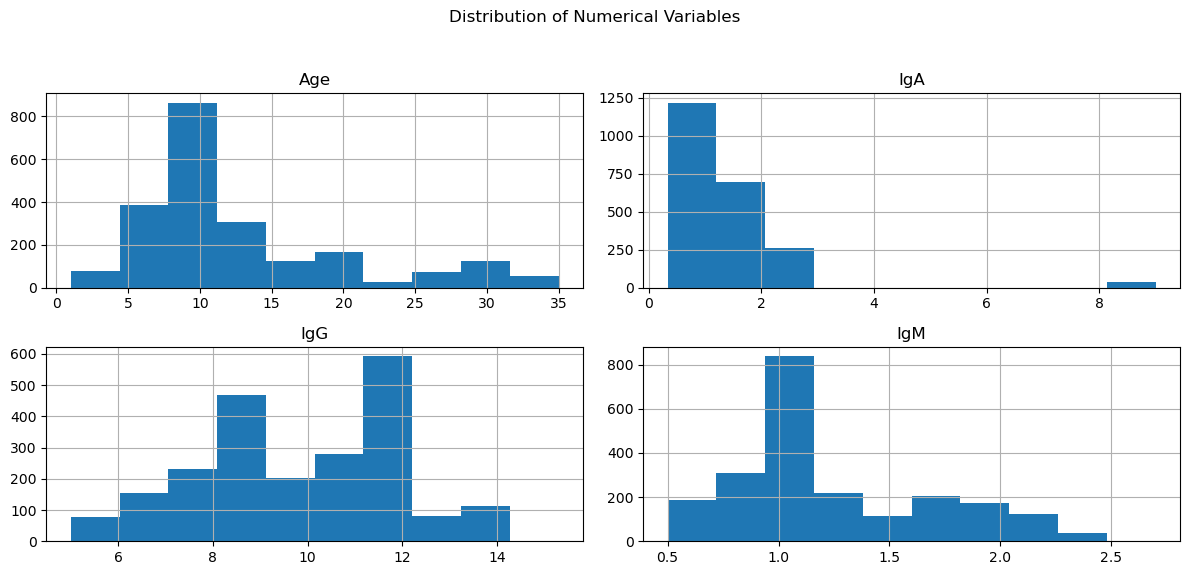

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].hist(bins=10, figsize=(12, 6), layout=(2, 2))
plt.suptitle('Distribution of Numerical Variables')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

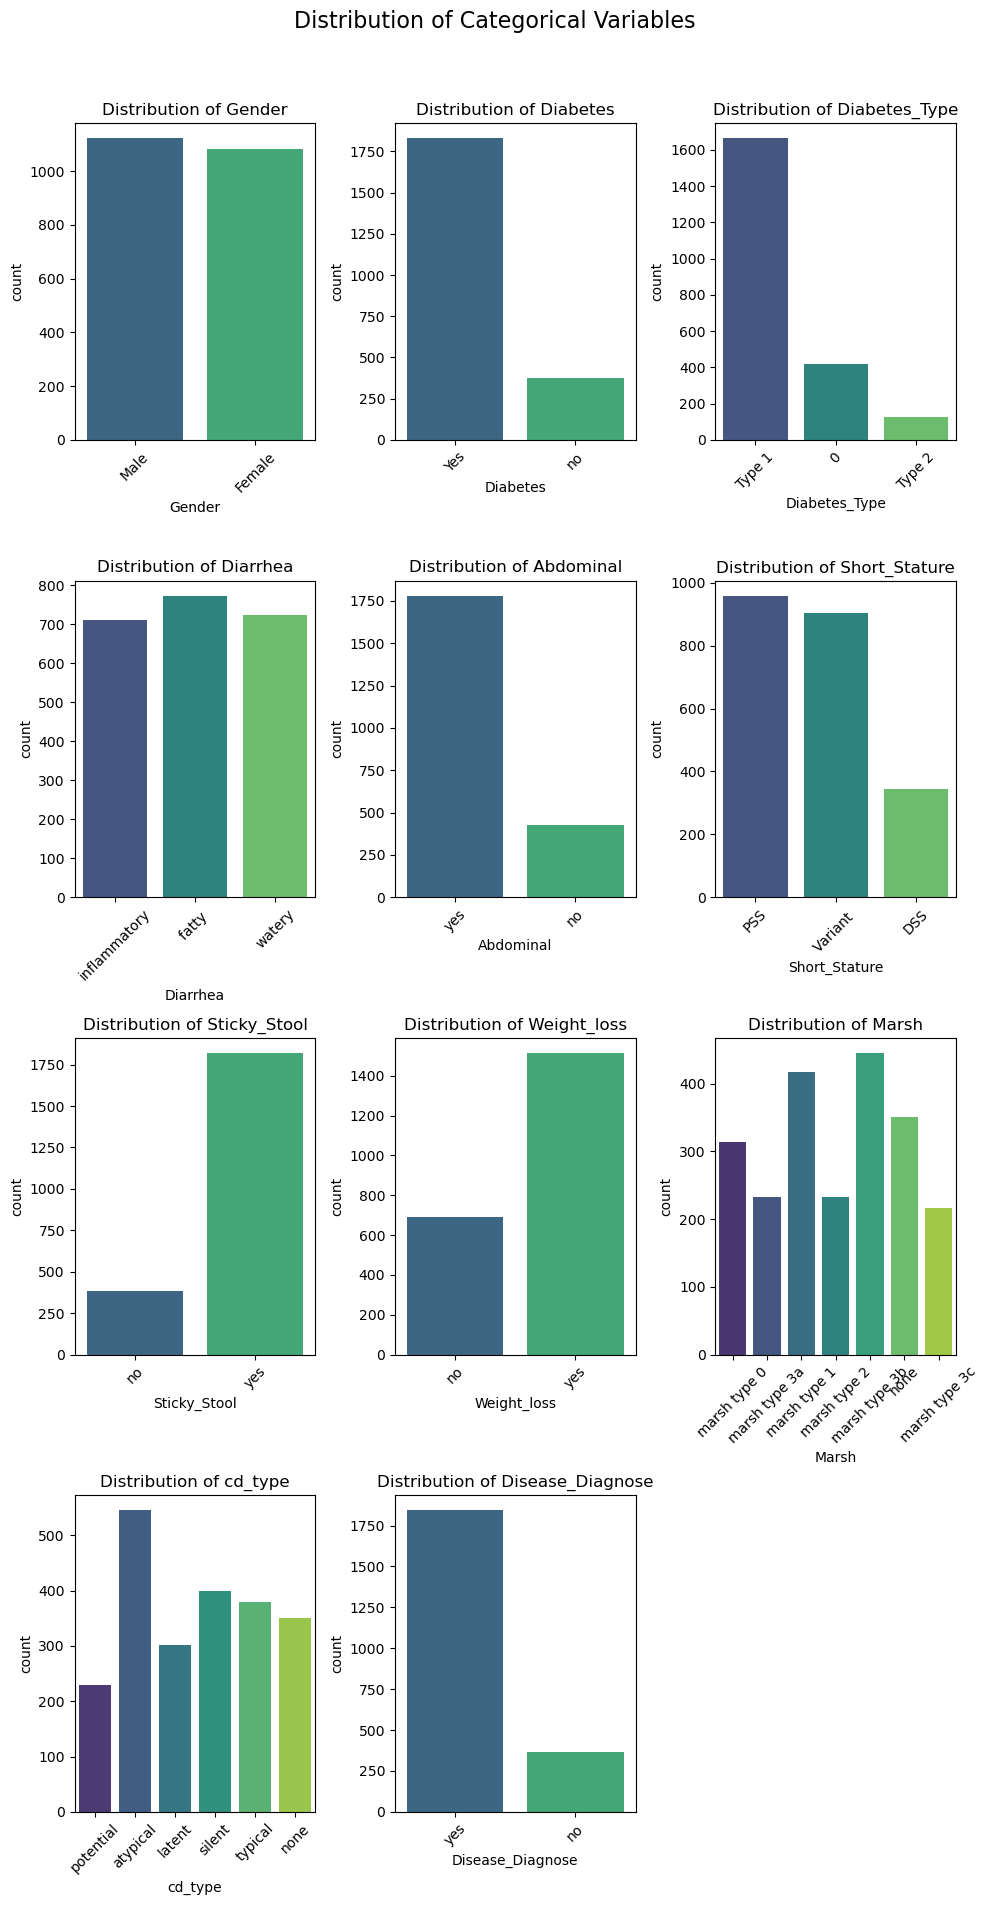

In [8]:
# get all categorical cols
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# build empty grid of subplots
num_cols = len(categorical_cols)
ncols = 3
# number of rows needed, rounding up
nrows = (num_cols + 1) // ncols 

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 5 * nrows))

# plot each categorical variable
for i, col_name in enumerate(categorical_cols):
    # flatten the axes array to make one 'row' from a 2D array
    ax = axes.flatten()[i] 
    # create countplot for each categorical variable
    sns.countplot(x=col_name, data=df, ax=ax, hue=col_name, palette='viridis', legend=False)
    # rotate x labels so graphs are readable
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'Distribution of {col_name}')

# hide last unused subplot
for i in range(num_cols, len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle('Distribution of Categorical Variables', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


It's important to look at these distributions and identify variables that are not normally distributed. This could come back to bite ue when we create ML models if certain categories are over or underrepresented. 

Here, my concern is the Diabetes variable. Most of this data was collected from people with diabetes, which may influence other symptoms. I'm not sure that the rest of these variables are independent of someone having diabetes. We can't do a lot about that now, but it's something to keep in mind going forward.

If it looks like this is a problem, we can cut out all of the subjects with diabetes. We'll look at the class distributions of all the non-diabetic subjects right now just to keep that option on the table for later if we need it.

In [9]:
# prevalence of celiac in dataset
celiac = df[df['Disease_Diagnose'] == 'yes']
rate = len(celiac) / len(df)
rate

0.8354487760652766

Another **major** point of concern is the Disease_Diagnose variable. The occurance of celiac is about 1% globally, and in this dataset, 83% of the subjects have celiac. Since the proportion of people with celiac in this dataset is so much bigger than it should be, this is not an accurate representation of the population. 

**What this means:**

We **cannot** use the data as is. The model would be completely biased and would have a very high Type II error rate. We're going to have to use bucket sampling to create a 50/50 split of celiac/no celiac. 

Before we can do this, we are going to need to finish cleaning the data. Let's move onto that.

Since only 4 of our variables are numeric, we will have to one-hot encode the rest of the 'object' variables. This will create several binary variables for each categorical variable. The 'Diabetes Type' variable has three levels, Type I, Type II, and None. Three binary variables need to be created for this, one binary indicator for Type I, one for Type II, and one for none. We are going to use pandas to do this automatically. Before we can start, we first need to convert some of the variables with only two levels to binary variables. 

The variables that need to be converted to binary are all of the yes/no variables in the dataframe.

Creating one binary variable instead of one-hot encoding and making multiple binary variables is more efficient and will make modeling just a little bit easier. 

This will apply to the 'Diabetes', 'Abdominal', 'Sticky_Stool', 'Weight_loss', and 'Disease_Diagnose' variables.

First, notice that in the original dataset, some of the answers are Yes with a capital Y and some are lowercase. We'll convert all of the y/n variabes to lowercase to prevent any case-sensitivity issues.

In [10]:
df['Diabetes'] = df['Diabetes'].str.lower()
df['Abdominal'] = df['Abdominal'].str.lower()
df['Sticky_Stool'] = df['Sticky_Stool'].str.lower()
df['Weight_loss'] = df['Weight_loss'].str.lower()
df['Disease_Diagnose'] = df['Disease_Diagnose'].str.lower()

Now we should have all lowercase yes and no values in these variables!

In [11]:
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


In [12]:
# Let's check how many yes/no values we have in the Diabetes column
df['Diabetes'].value_counts()

Diabetes
yes    1829
no      377
Name: count, dtype: int64

In [13]:
# overwrite the 'Diabetes' col with 1s for yes and 0s otherwise
df['Diabetes'] = np.where(df['Diabetes'] == 'yes', 1, 0)
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,1,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,1,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,1,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,1,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,1,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


Let's check how many 1/0 values we have in the Diabetes column

In [14]:
# Here's what we had before:
# Diabetes
# yes    1829
# no      377
# Name: count, dtype: int64
df['Diabetes'].value_counts()

Diabetes
1    1829
0     377
Name: count, dtype: int64

Our counts line up, so we've correctly transformed this variable! Let's do the same for the remaining binary variables. 

In [15]:
# First, we will get the initial value counts so we can check our work
df['Abdominal'].value_counts()

Abdominal
yes    1781
no      425
Name: count, dtype: int64

In [16]:
# Next, we will convert the 'Abdominal' column to 1s and 0s
df['Abdominal'] = np.where(df['Abdominal'] == 'yes', 1, 0)

In [17]:
# Finally, we will check our work
df['Abdominal'].value_counts()

Abdominal
1    1781
0     425
Name: count, dtype: int64

In [18]:
df['Sticky_Stool'].value_counts()

Sticky_Stool
yes    1820
no      386
Name: count, dtype: int64

In [19]:
df["Sticky_Stool"] = np.where(df["Sticky_Stool"] == 'yes', 1, 0)
df["Sticky_Stool"].value_counts()

Sticky_Stool
1    1820
0     386
Name: count, dtype: int64

In [20]:
df['Weight_loss'].value_counts()

Weight_loss
yes    1514
no      692
Name: count, dtype: int64

In [21]:
df["Weight_loss"] = np.where(df["Weight_loss"] == 'yes', 1, 0)
df["Weight_loss"].value_counts()

Weight_loss
1    1514
0     692
Name: count, dtype: int64

In [22]:
df['Disease_Diagnose'].value_counts()

Disease_Diagnose
yes    1843
no      363
Name: count, dtype: int64

In [23]:
df["Disease_Diagnose"] = np.where(df["Disease_Diagnose"] == 'yes', 1, 0)
df["Disease_Diagnose"].value_counts()

Disease_Diagnose
1    1843
0     363
Name: count, dtype: int64

In [24]:
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,1,Type 1,inflammatory,1,PSS,0,0,1.30,10.0,1.00,marsh type 0,potential,1
1,9,Male,1,Type 1,fatty,1,PSS,0,0,1.50,12.5,1.30,marsh type 3a,atypical,1
2,8,Female,1,Type 1,watery,1,Variant,1,1,0.40,8.0,0.50,marsh type 1,latent,1
3,10,Male,1,Type 1,watery,1,PSS,0,0,0.98,9.0,0.66,marsh type 3a,silent,1
4,9,Male,1,Type 1,fatty,1,PSS,0,0,1.00,10.5,1.10,marsh type 1,latent,1


Since there are only two options for Gender, we will code Male as 1 and Female as 0

In [25]:
df['Gender'] = np.where(df['Gender'] == 'Male', 1, 0)
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,1,1,Type 1,inflammatory,1,PSS,0,0,1.30,10.0,1.00,marsh type 0,potential,1
1,9,1,1,Type 1,fatty,1,PSS,0,0,1.50,12.5,1.30,marsh type 3a,atypical,1
2,8,0,1,Type 1,watery,1,Variant,1,1,0.40,8.0,0.50,marsh type 1,latent,1
3,10,1,1,Type 1,watery,1,PSS,0,0,0.98,9.0,0.66,marsh type 3a,silent,1
4,9,1,1,Type 1,fatty,1,PSS,0,0,1.00,10.5,1.10,marsh type 1,latent,1


Now, we should recheck our datatypes to determine which variables we have to one-hot encode.

In [26]:
df.dtypes

Age                   int64
Gender                int32
Diabetes              int32
Diabetes_Type        object
Diarrhea             object
Abdominal             int32
Short_Stature        object
Sticky_Stool          int32
Weight_loss           int32
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose      int32
dtype: object

# remove variables causing data leakage

In [26]:
df = df.drop(columns=['IgA','IgG', 'IgM','Marsh', 'cd_type'])

In [27]:
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,Disease_Diagnose
0,10,1,1,Type 1,inflammatory,1,PSS,0,0,1
1,9,1,1,Type 1,fatty,1,PSS,0,0,1
2,8,0,1,Type 1,watery,1,Variant,1,1,1
3,10,1,1,Type 1,watery,1,PSS,0,0,1
4,9,1,1,Type 1,fatty,1,PSS,0,0,1


# now we only have the appropriate variables

Time to one-hot encode all of our categorical features! We will use one of the pandas methods, get_dummies. This will only apply to the object datatypes, so we don't need to repeat it for every variable we want to encode. I am going to overwrite our original dataframe with the one-hot encoded variables.

In [28]:
df = pd.get_dummies(df, columns=['Diabetes_Type', ], prefix='DiabetesType')

In [29]:
# Since the label for each column auto filled, we're going to change DiabetesType_0 to Diabetes_Type_None
df = df.rename(columns={'DiabetesType_0': 'Diabetes_Type_None'})
#df.head()
# much better :)

Since we know (based on variable type) which variables we need one-hot encode, we can do the rest of them in one command rather than doing each individually!

In [30]:
df = pd.get_dummies(df,drop_first=True)

Let's look at our new dataframe

In [31]:
df.head()

,Age,Gender,Diabetes,Abdominal,Sticky_Stool,Weight_loss,Disease_Diagnose,Diabetes_Type_None,DiabetesType_Type 1,DiabetesType_Type 2,Diarrhea_inflammatory,Diarrhea_watery,Short_Stature_PSS,Short_Stature_Variant
0,10,1,1,1,0,0,1,False,True,False,True,False,True,False
1,9,1,1,1,0,0,1,False,True,False,False,False,True,False
2,8,0,1,1,1,1,1,False,True,False,False,True,False,True
3,10,1,1,1,0,0,1,False,True,False,False,True,True,False
4,9,1,1,1,0,0,1,False,True,False,False,False,True,False


# gave up on copying over text

In [32]:
y = df['Disease_Diagnose']
x = df.drop('Disease_Diagnose', axis=1)

In [33]:
X_main, X_test, y_main, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [34]:
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.125, stratify=y_main, random_state=42)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [36]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
coefficients = log_model.coef_
intercept = log_model.intercept_

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Coefficients: [[-0.01795738  0.07483763  3.7381712   1.1616754  -0.05456395  0.58835763
  -0.5710149   0.44026694  0.09151385 -0.53418071 -0.11233723  0.23002004
  -0.79795338]]
Intercept: [-1.19197143]


In [38]:
log_model.predict(X_test)

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,

In [39]:
y_pred_log = log_model.predict(X_test)
# evaluate the model
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76        73
           1       0.95      0.95      0.95       369

    accuracy                           0.92       442
   macro avg       0.86      0.85      0.86       442
weighted avg       0.92      0.92      0.92       442

[[ 55  18]
 [ 17 352]]


In [44]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [53]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

In [54]:
y_pred_lasso = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Mean Squared Error: {mse}")
print(f"Coefficients: {lasso_model.coef_}")

Mean Squared Error: 0.12414926527378013
Coefficients: [ 0.00468324 -0.          0.06271662  0.          0.          0.
 -0.          0.          0.         -0.          0.          0.
 -0.        ]


In [55]:
final_feature_names = df.columns
coef_dict = dict(zip(final_feature_names, lasso_model.coef_))

coef_df = pd.DataFrame(coef_dict.items(), columns=['Variable', 'Coefficient'])

# Sort by absolute coefficient value to easily see the most influential variables
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

# Drop the helper column and print
coef_df = coef_df.drop('Absolute_Coefficient', axis=1)

print("Lasso Coefficients (sorted by magnitude):")
# To ensure all columns are visible in the output
pd.set_option('display.max_columns', None) 
print(coef_df)

Lasso Coefficients (sorted by magnitude):
                 Variable  Coefficient
2                Diabetes     0.062717
0                     Age     0.004683
1                  Gender    -0.000000
3               Abdominal     0.000000
4            Sticky_Stool     0.000000
5             Weight_loss     0.000000
6        Disease_Diagnose    -0.000000
7      Diabetes_Type_None     0.000000
8     DiabetesType_Type 1     0.000000
9     DiabetesType_Type 2    -0.000000
10  Diarrhea_inflammatory     0.000000
11        Diarrhea_watery     0.000000
12      Short_Stature_PSS    -0.000000
